In [1]:
import numpy as np
import matplotlib.pyplot as plt
import neutrino_TPI as nmc
import definition as df
import multiprocessing as mp
from functools import partial
import platform

print(platform.architecture())

print(nmc.sr_gl(30, 10, 0.01))

E_nu_0 = 30
x_max = 100
x_0_list = np.logspace(-2, 3, x_max) 
log_m_phi_space = np.concatenate((np.linspace(0, 2, 500), np.linspace(2, 4, 2500)))

('64bit', 'WindowsPE')
3.648143899054711e-50


(100, 3000)


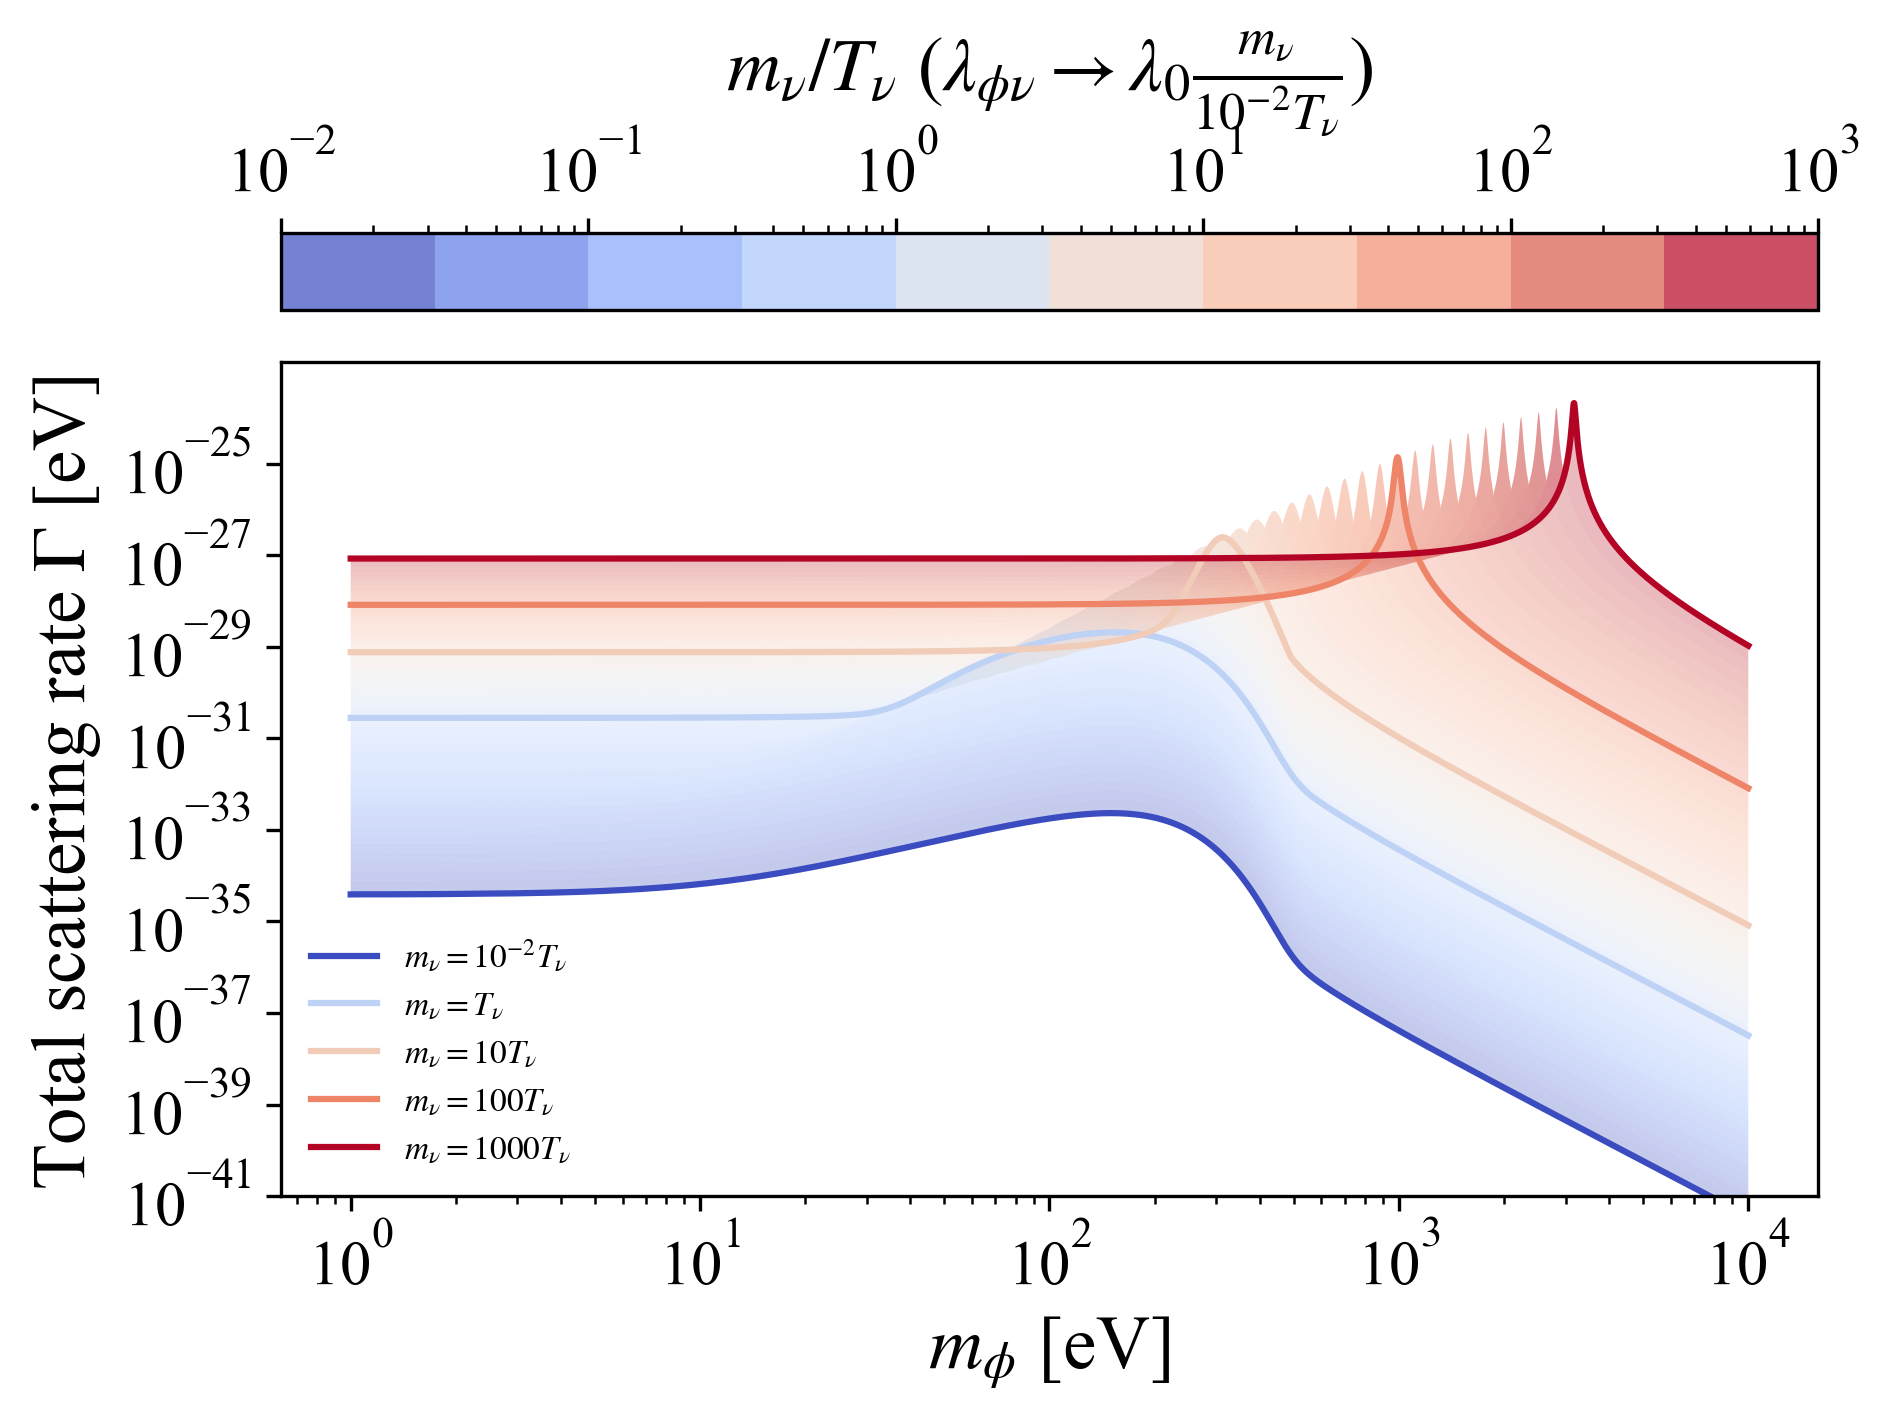

In [4]:
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from scipy.signal import savgol_filter  # Import the smoothing filter
from scipy.interpolate import InterpolatedUnivariateSpline as IUS
import definition as df

# print(plt.colormaps())
# print(y_values_array_max[0])

my_colors = ["purple", "hotpink", "orange", 'white']
# cmap = LinearSegmentedColormap.from_list("my_custom_map", my_colors, N=256)

color = 'coolwarm'  # Choose a built-in colormap that goes from purple to red

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix' # STIX fonts look very similar to Times New Roman

cmap = plt.get_cmap(color)  # Use a built-in colormap that goes from purple to red
norm = LogNorm(vmin=x_0_list.min(), vmax=x_0_list.max())

y_values = np.load("./Data/scat_rate.npy")

lambda_phi = 1e-8*x_0_list*1e2

for i in range(len(x_0_list)):
    y_values[i] = y_values[i]*lambda_phi[i]**2

print(y_values.shape)

fig, ax = plt.subplots(dpi=300)
# y_values_smoothed = savgol_filter(y_values, window_length=4, polyorder=1, axis=1)  # Smooth each row

ratio = int(2)
for i, x_0 in enumerate(x_0_list):
    if i == 0:
        ax.fill_between(10**log_m_phi_space, y_values[i], y_values[i+1], color=cmap(norm(x_0_list[i])), alpha=0.3, edgecolor='none')
    elif (i+1) % ratio == 0:  # Plot every 'ratio' lines to reduce clutter
        if i < len(x_0_list) - 1:
            ax.fill_between(10**log_m_phi_space, y_values[i], y_values[i+ratio], color=cmap(norm(x_0_list[i])), alpha=0.3, edgecolor='none')
        

# or
# for i, x_0 in enumerate(x_0_list):
#     if i < len(x_0_list) - 1:
#         ax.fill_between(m_phi_space, y_values[i], y_values[i+1], color=cmap(norm(x_0_list[i])), alpha=0.12, edgecolor='none')

    # ax.fill_between(m_phi_space, y_values[57], y_values[59], color=cmap(norm(x_0_list[57])), alpha=0.01, edgecolor='none')     
        # ax.fill_between(m_phi_space, y_values[i], y_values[i+1], color=cmap(norm(x_0_list[i])),  alpha=0.15,  edgecolor='none')     # Ensures no edge color is drawn)

    # if i == len(x_0_list)-1:
    #     ax.fill_between(m_phi_space, y_values[i], y_values[i-4], color=cmap(norm(x_0_list[i])), alpha=0.1)


ax.plot(10**log_m_phi_space, y_values[0], color=cmap(norm(x_0_list[0])), linestyle='-', label=r'$m_\nu = 10^{-2}T_\nu$')
ax.plot(10**log_m_phi_space, y_values[int(2/5 * x_max -1)], color=cmap(norm(x_0_list[int(2/5 * x_max -1)])), linestyle='-', label=r'$m_\nu = T_\nu$')
ax.plot(10**log_m_phi_space, y_values[int(3/5 * x_max -1)], color=cmap(norm(x_0_list[int(3/5 * x_max -1)])), linestyle='-', label=r'$m_\nu = 10T_\nu$')
ax.plot(10**log_m_phi_space, y_values[int(4/5 * x_max -1)], color=cmap(norm(x_0_list[int(4/5 * x_max -1)])), linestyle='-', label=r'$m_\nu = 100T_\nu$')
ax.plot(10**log_m_phi_space, y_values[int(x_max -1)], color=cmap(norm(x_0_list[int(x_max -1)])), linestyle='-', label=r'$m_\nu = 1000T_\nu$')

label_fontsize = 18
tick_fontsize = 15

ax.set_xlabel(r"$m_\phi$ [eV]", fontsize=label_fontsize)
ax.set_ylabel(r"Total scattering rate $\Gamma$ [eV] ", fontsize=label_fontsize)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-41, None)
# ax.set_xlim(10**log_m_phi_space.min(), 1e5)
ax.set_yticks([1e-41,1e-39,1e-37,1e-35,1e-33,1e-31,1e-29,1e-27,1e-25])
# ax.set_ylim(1e-4, 1e1)
# ax.set_xlim(m_phi_space.min(), m_phi_space.max())

ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.legend(fontsize=12, loc='lower left', frameon=False)

cmap = plt.get_cmap(color, 10) 
sm = ScalarMappable(cmap = cmap, norm = norm)
sm.set_array([]) 

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', location='top',extend='neither',pad=0.05, alpha = 0.7)
cbar.set_label(r"$m_\nu / T_\nu$ ($\lambda_{\phi\nu} \rightarrow \lambda_0\frac{m_\nu}{10^{-2}T_\nu}$)", fontsize=label_fontsize, labelpad=10)
cbar.ax.tick_params(labelsize=tick_fontsize)

plt.legend(fontsize=8, loc='lower left', frameon=False)
plt.tight_layout()
# plt.savefig("F:/Neutrino_SI/Plots/normalized_rate_new.pdf")  
fig
